In [89]:
from pathlib import Path
from typing import Sequence

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

import omegaconf

In [90]:
path = "../../"
path = Path(path).expanduser()
import sys
sys.path.insert(0, str(path))

In [91]:
import decode
import decode.neuralfitter.inference.functional as infer_func

from decode.utils import param_auto, system, hardware
print(decode.__file__)
log = decode.generic.logging.get_logger(__name__)

%config InlineBackend.figure_format='retina'

/home/shahao/projects/DECODE-Plex/notebook/debug/../../decode/__init__.py


In [ ]:
path_frames = "../../data/Fig2c-240619_NC_LivingCell_HMSir_Tub_i20_2/"
path_frames = Path(path_frames).expanduser()

path_trafo = "../../calibration/Fig1c_2c-Pos0_240621_NC_BeadCal_BifocalPlane_Z_1_MMStack_Default.ome_trafo.mat"
path_trafo = Path(path_trafo).expanduser()

######################SMAP#############################
from hydra import initialize, compose
from omegaconf import OmegaConf

CONFIG_ROOT = "../../config/"

with initialize(version_base="1.2", config_path=CONFIG_ROOT):
    cfg_hydra = compose(config_name="param_run_Fig2c-biplane-live_cell")

cfg = OmegaConf.to_container(cfg_hydra, resolve=True)

auto_cfg = param_auto.AutoConfig(
    fill=False,
    fill_test=True,
    auto_scale=True,
    return_type=omegaconf.DictConfig,
    ref={},
)
cfg = auto_cfg.parse(cfg)

2026-04-27 11:34:27 [info     ] Running experimental function `_auto_channel_maps` tested=False


In [93]:
from decode.io.frames import TiffTensor 

mode_camera = "rois"
bulk_load = False
pframe = sorted(path_frames.glob("*.tif"))[0]
frames = decode.io.frames.load_tif(pframe, auto_ome=False, memmap=True)
print(f"Paths: \n{pframe}\nsize: {frames.size()}")

if isinstance(frames, TiffTensor):
    frames = torch.stack([frames[i] for i in range(len(frames))])
    # ###### Rearrange channels if reference is different ######
    # up_framse = frames[:,:frames.shape[1]//2,:]
    # down_framse = frames[:,frames.shape[1]//2:,:]
    # frames = torch.cat([down_framse, up_framse], dim=1)  # (N, C, H, W)


Paths: 
../../data/240619_NC_LivingCell_HMSir_Tub_i20_2/240619_NC_LivingCell_HMSir_Tub_i20_2_MMStack_Default.ome.tif
size: torch.Size([10000, 512, 248])


In [94]:
from decode.neuralfitter.train import setup_cfg

pre = setup_cfg.setup_frame_pre_multi_roi(
                        cfg, cfg["Camera"][0]["specs"], "cpu", "Test", (256, 226)
                    )

frame_pre = pre.forward(frames)

2026-04-27 11:34:33 [info     ] Setting up frame pre-processing in multi-roi mode, on a single camera.
2026-04-27 11:34:33 [info     ] Offsetted transformation, adjusting frame in 2nd channel. offset=(43, -12)


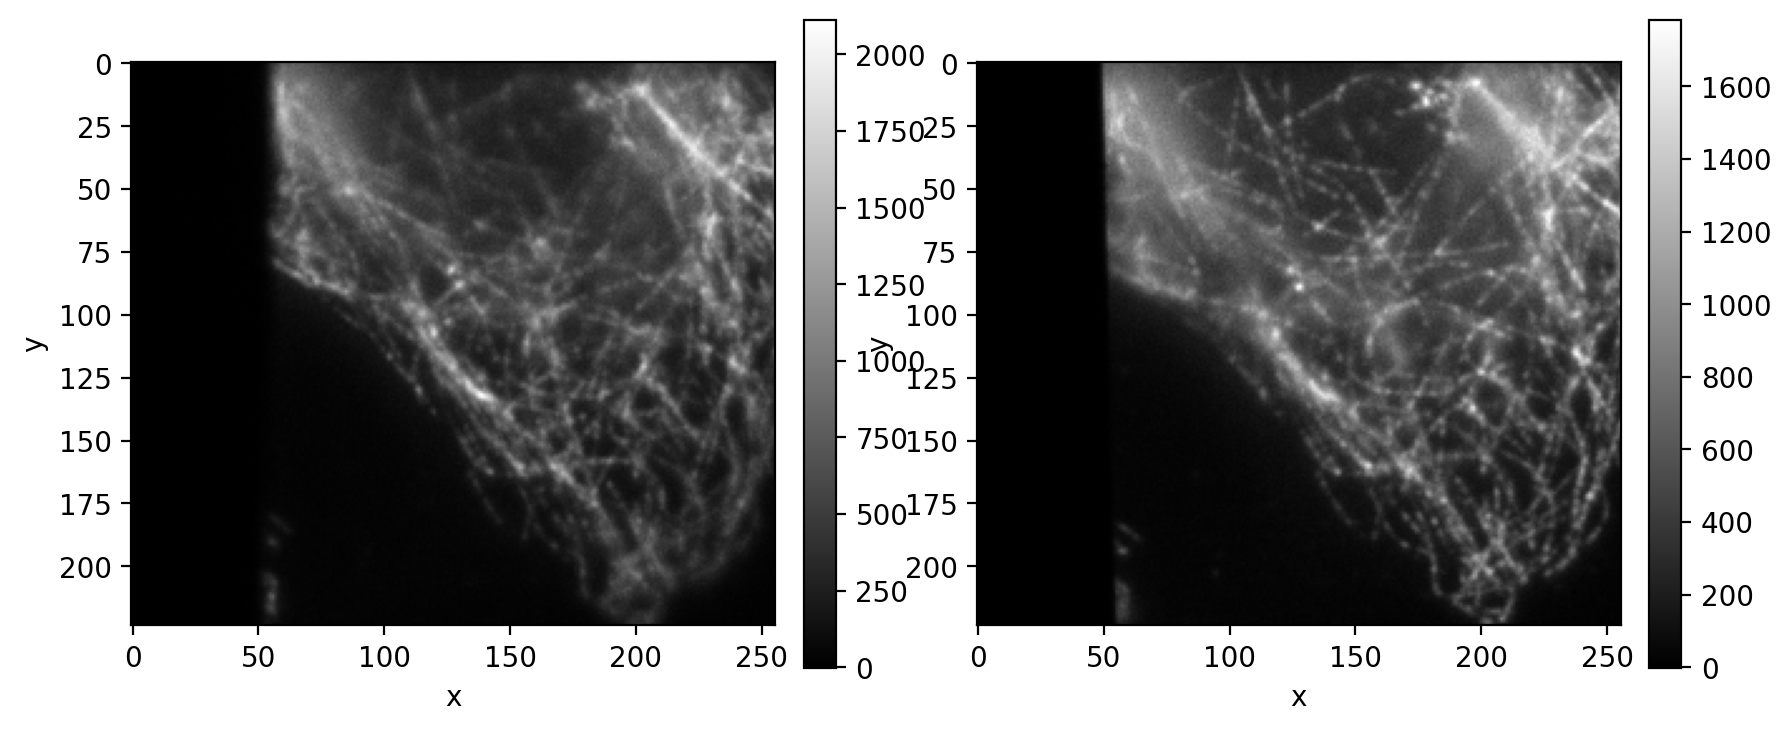

In [95]:
f_ix = 51
f, ax = plt.subplots(1, 2, figsize=(10, 5))
plt.sca(ax[0])
decode.plot.PlotFrameCoord(
    frame_pre[0][f_ix], # .flip(-1),
).plot()

plt.sca(ax[1])
decode.plot.PlotFrameCoord(
     frame_pre[1][f_ix]#.flip(-2),# .flip(-1),
).plot()


In [96]:
path = path_trafo if isinstance(path_trafo, Path) else Path(path_trafo)
device = "cpu"

from decode.neuralfitter.train.setup_cfg import setup_trafo
trafo_ = setup_trafo(cfg, device)

2026-04-27 11:34:39 [info     ] Loading transformation.        path=/home/shahao/projects/DECODE-Plex/calibration/Pos0_240621_NC_BeadCal_BifocalPlane_Z_1_MMStack_Default.ome_trafo.mat reference=trafo_inv_raw
2026-04-27 11:34:39 [info     ] Running experimental function `load_xyz_trafo` tested=True
2026-04-27 11:34:39 [info     ] De-mirroring transformation.   ch=1 dim=0 size_reference=512
2026-04-27 11:34:39 [info     ] Offsets as specified in config.
2026-04-27 11:34:39 [debug    ] Final transformation.          trafo=XYZCompositTransformation([
    XYZShiftTransformation(tensor([1., 1., 0.]), cpu),
    XYZScaleTransformation(0.0010000000474974513, global),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x71763a154ee0>, None, cpu, True),
    XYZTransformationMatrix(tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.0016, -0.0362,  0.0020],
         [-0.0362, -1.0010,  0.0012],
         [ 0.017

In [ ]:
###### For uiPSF trafo debugging only ######
from decode.io.psf import load_h5
from decode.simulation.trafo.pos import trafo

def _coord_permute_smap(xyz: torch.Tensor) -> torch.Tensor:
    return xyz[..., [1, 0, 2]]

data, p = load_h5(path_trafo)
f = data
trafo_mat = torch.tensor(data.res.T)
trafo_mat = trafo_mat.unsqueeze(0) if trafo_mat.dim()==2 else trafo_mat
trafo_mat = torch.cat([torch.eye(3).unsqueeze(0),trafo_mat]) # save the first channel 

shift = (-data.res.imgcenter[1], -data.res.imgcenter[0], 0) 
# shift = (-128.0, -256.0, 0) 

t = trafo.XYZTransformationMatrix(trafo_mat)

permute_in = trafo.XYZTransformationGeneric(
    _coord_permute_smap,
    device=device,
    device_arbitrary=True,
)
permute_out = permute_in
t = [t]
t.insert(0, permute_in)
t.append(permute_out)
t = trafo.XYZCompositTransformation(t)

t = trafo.offset_trafo(t, offset=shift, rebound=True)

offset = (f.res.xyshift[:,[1,0]]-0.5).astype(int).tolist()

shift_ch0 = [0,0,0]
shift_ch1 = offset[1] + [0]
shift_ch1[1] = -shift_ch1[1]
shift_ch1[0] = -shift_ch1[0]

trafo_shift = trafo.XYZShiftTransformation(
shift_ch1, device=device
)
trafo_shift = trafo.XYZChanneledTransformation(trafo_shift, 1)

# final trafo
t.append(trafo_shift)
print(t)


xyz_px = torch.tensor([[ 101.1171, 111.6648,0]])
print(t.forward(xyz_px))



In [ ]:
###### For uiPSF trafo debugging only ######
ref_pos = data.res.channel0.pos
pos = data.res.channel1.pos

cor_ref = np.concatenate((ref_pos[:,1:], np.ones((ref_pos.shape[0], 1))), axis=1)

cor_target = np.matmul(cor_ref-data.res.imgcenter, data.res.T)[..., :-1]+data.res.imgcenter[:-1]
print(cor_target[28])
print(cor_ref[28,:])
print(t.forward(torch.tensor([cor_ref[28,:].astype(np.float32).tolist()])))
print(pos[28])

tensor([[121.3400,  82.5519,   0.0000]])


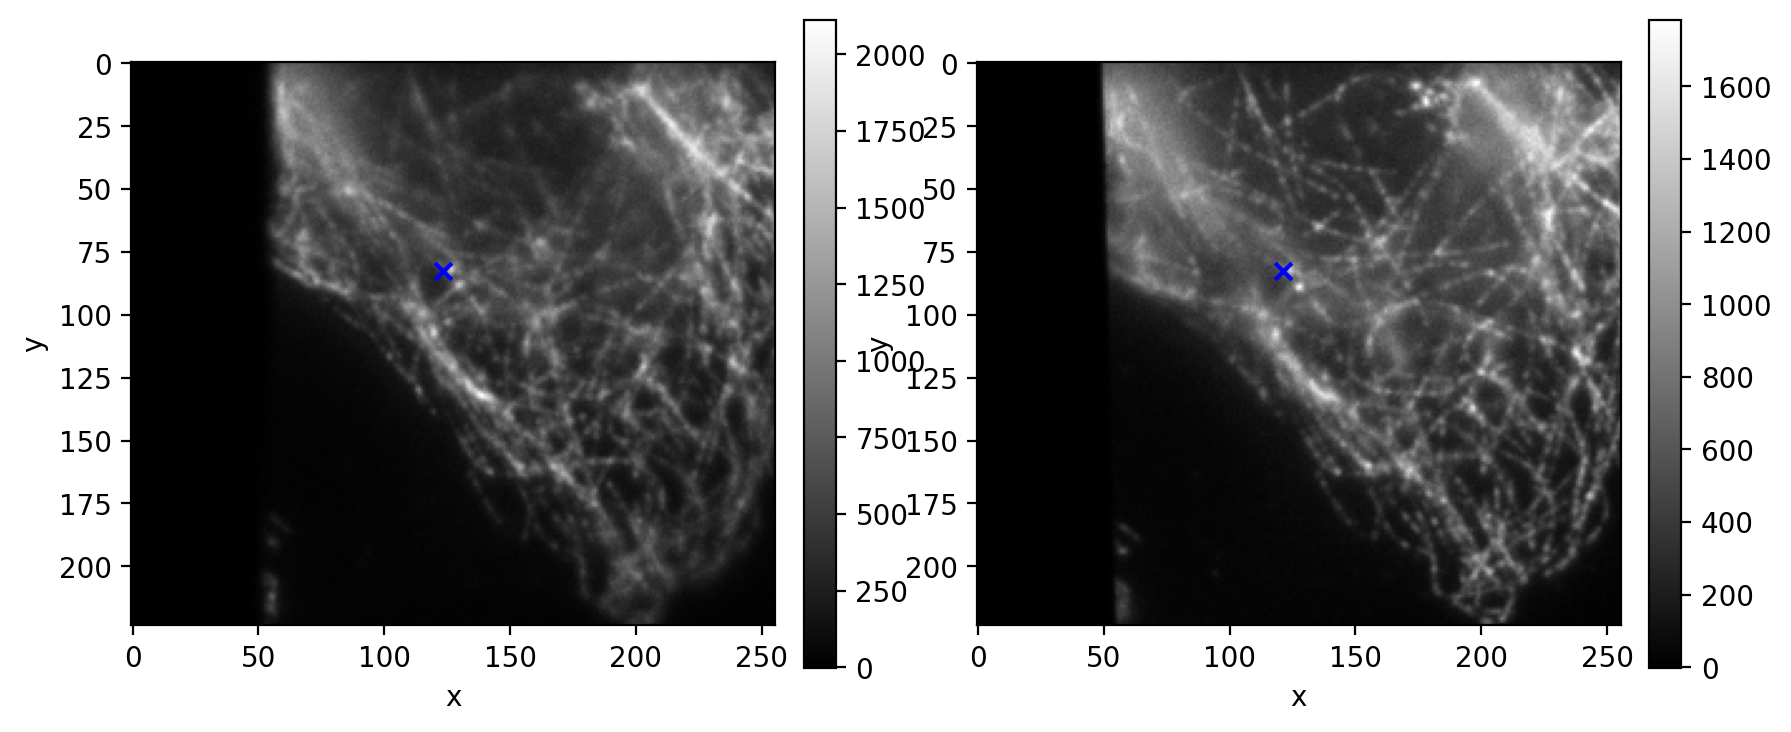

In [97]:
f_ix = 51

choric = decode.simulation.trafo.photon.trafo.MultiChoricSplitter(
    torch.tensor([[0.5, 0.5]])
)

import numpy
xyz_px = torch.tensor([[123.5,82.5,0]])

print(trafo_.forward(xyz_px)[:,1,:])
f, ax = plt.subplots(1, 2, figsize=(10, 5))
# plt.sca(ax[0])
# decode.plot.PlotFrameCoord(
#     frames[f_ix][:256, :], # .flip(-1),
#     pos_out= xyz_px# torch.tensor(cor_ref[...,[1,0,2]])
# ).plot()

# plt.sca(ax[1])
# decode.plot.PlotFrameCoord(
#      frames[f_ix][256:,:].flip(-2),# .flip(-1),
#     pos_out= t.forward(xyz_px)[:,1,:] # + torch.tensor([0,+23,0])
# ).plot()

plt.sca(ax[0])
decode.plot.PlotFrameCoord(
    frame_pre[0][f_ix],
    pos_out=xyz_px
).plot()

plt.sca(ax[1])
decode.plot.PlotFrameCoord(
    frame_pre[1][f_ix],
    pos_out= trafo_.forward(xyz_px)[:,1,:] # + torch.tensor([1,-1,0])
).plot()



Paths: 
/home/shahao/projects/DECODE_Internal/data/MM_25ms_638i100_UVi20_focusloci30_1/MM_25ms_638i100_UVi20_focusloci30_1_MMStack_Default.ome.tif
size: torch.Size([16742, 512, 226])
2026-02-08 13:33:55 [info     ] Setting up frame pre-processing in multi-roi mode, on a single camera.
2026-02-08 13:33:55 [info     ] Offsetted transformation, adjusting frame in 2nd channel. offset=(-33, 5)


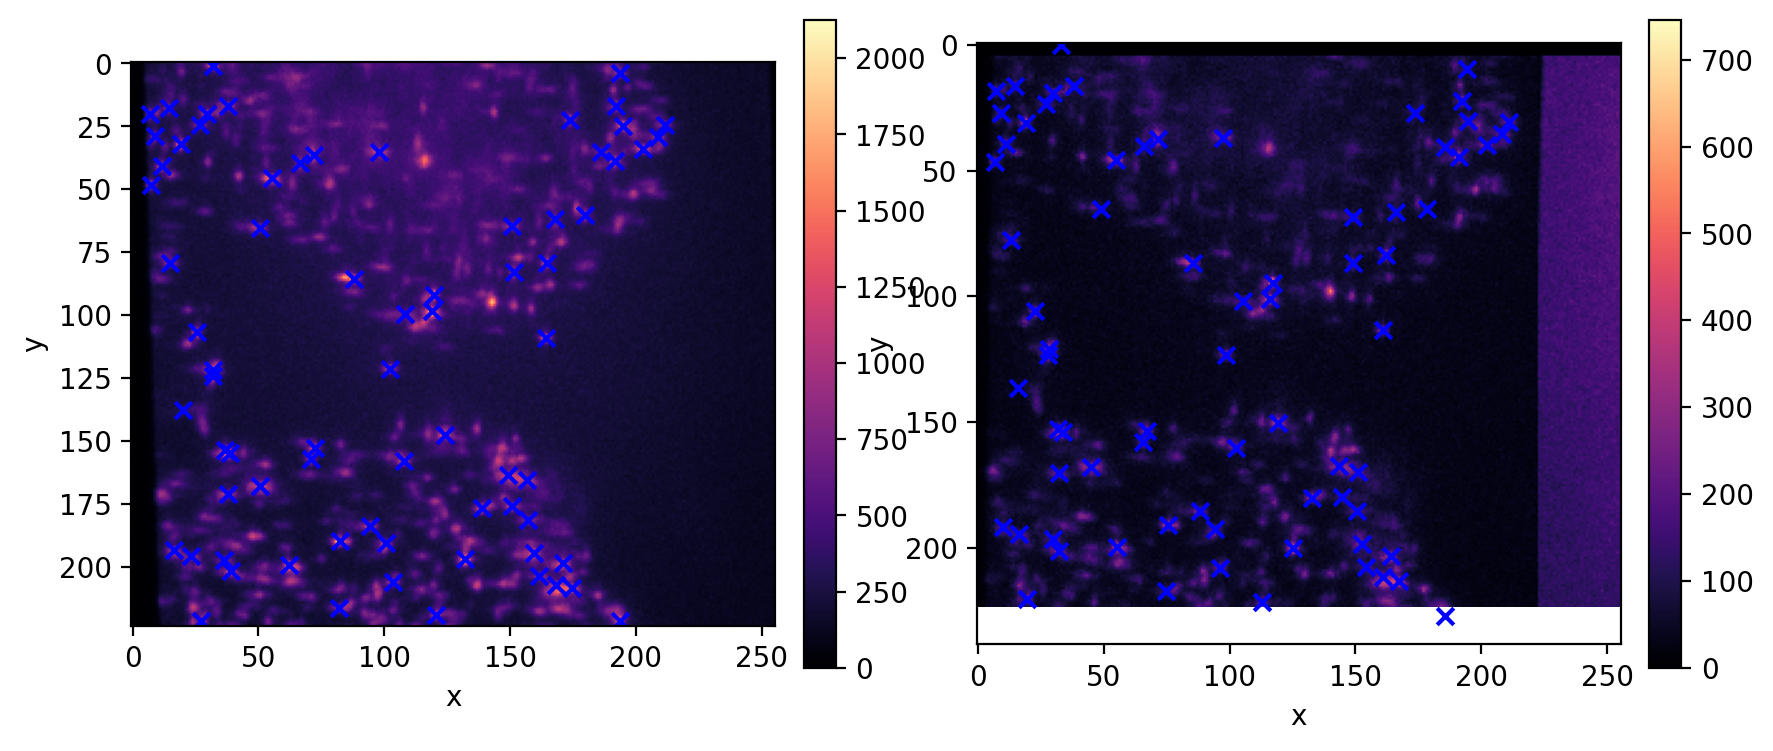

In [ ]:
from decode.neuralfitter.train import setup_cfg
em = decode.EmitterSet.load("../../data/Fig2a-MM_25ms_638i100_UVi20_focusloci30_1/MM_25ms_638i100_UVi20_focusloci30_1_MMStack_Default.ome_decode_plex_fit_model_2026-02-07_20-32-31-575689.h5")


from decode.io.frames import TiffTensor 

path_frames = "../../data/Fig2a-MM_25ms_638i100_UVi20_focusloci30_1"
path_frames = Path(path_frames).expanduser()
mode_camera = "rois"
bulk_load = False
pframe = sorted(path_frames.glob("*.tif"))[0]
frames = decode.io.frames.load_tif(pframe, auto_ome=False, memmap=True)
print(f"Paths: \n{pframe}\nsize: {frames.size()}")

if isinstance(frames, TiffTensor):
    frames = torch.stack([frames[i] for i in range(len(frames))])

    ###### Rearrange channels if reference is different ######
    up_framse = frames[:,:frames.shape[1]//2,:]
    down_framse = frames[:,frames.shape[1]//2:,:]
    frames = torch.cat([down_framse, up_framse], dim=1)  # (N, C, H, W)



pre = setup_cfg.setup_frame_pre_multi_roi(
                        cfg, cfg["Camera"][0]["specs"], "cpu", "Test", (256, 226)
                    )
frame_pre = pre.forward(frames)

f_ix = 15500

choric = decode.simulation.trafo.photon.trafo.MultiChoricSplitter(
    torch.tensor([[0.5, 0.5]])
)

xyz_px_ = torch.tensor([[90.5,117.5,0]])

em_ch = em.clone()
em_ch = em_ch[em_ch.prob > 0.99]
em_ch = em_ch[em_ch.phot[:,0] > 15000]
em_ch.xyz_px = trafo_.forward(em_ch.xyz_px)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
plt.sca(ax[0])
decode.plot.PlotFrameCoord(
    frame_pre[0][f_ix],
    pos_out= em_ch.iframe[f_ix].xyz_px[:, 0] # xyz_px_
).plot()

plt.sca(ax[1])
decode.plot.PlotFrameCoord(
    frame_pre[1][f_ix],
    # pos_ini=smap_em_ch.iframe[f_ix].xyz_px[:, 1],
    pos_out= em_ch.iframe[f_ix].xyz_px[:, 1]#+ torch.tensor([-1,1,0])# trafo_.forward(xyz_px_)[:,1,:]
).plot()

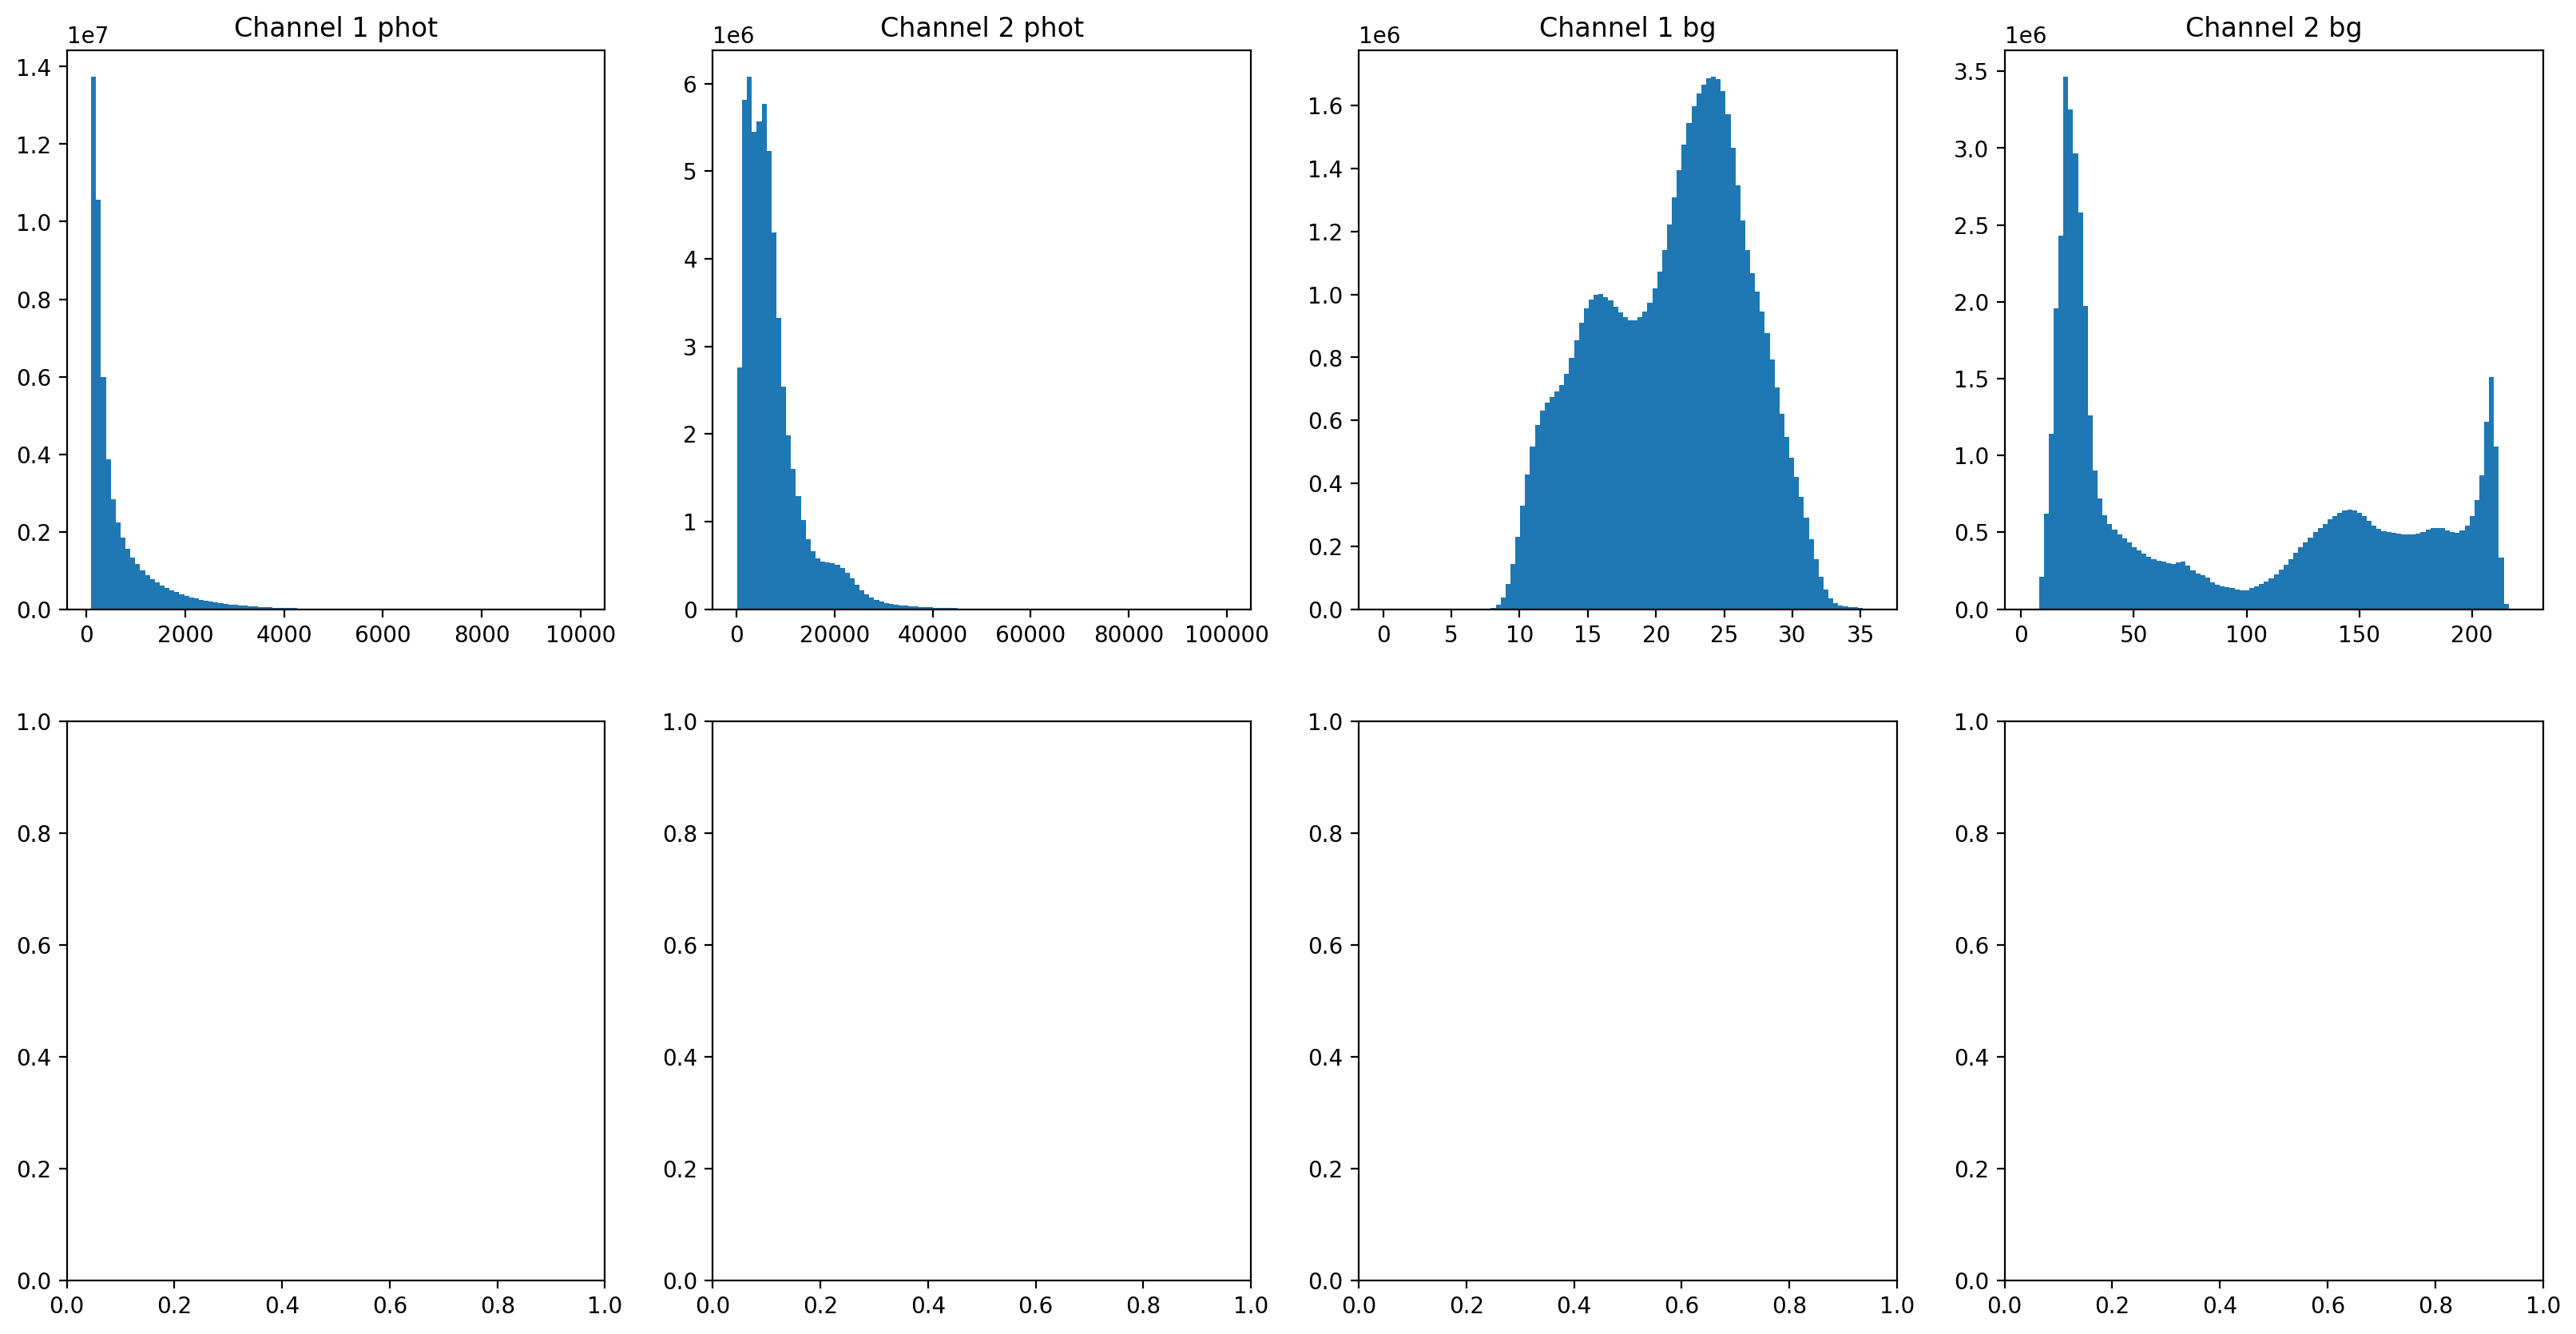

In [20]:
f, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, r in enumerate([-1]):
    em_c = em

    axs[i, 0].hist(em_c.phot[:, 0].numpy(), bins=100, range=(1e2, 1e4))
    axs[i, 1].hist(em_c.phot[:, 1].numpy(), bins=100, range=(1e2, 1e5))
    axs[i, 2].hist(em_c.bg[:, 0].numpy(), bins=100)
    axs[i, 3].hist(em_c.bg[:, 1].numpy(), bins=100)

    if i == 0:
        axs[i, 0].set_title("Channel 1 phot")
        axs[i, 1].set_title("Channel 2 phot")
        axs[i, 2].set_title("Channel 1 bg")
        axs[i, 3].set_title("Channel 2 bg")